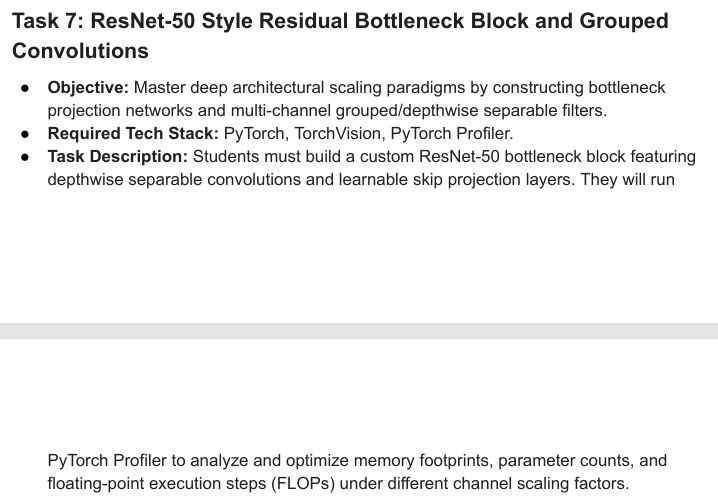

In [1]:
!pip install torch torchvision matplotlib

In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.profiler import profile, record_function, ProfilerActivity

In [3]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [4]:
x = torch.randn(
    2, 64, 32, 32
).to(device)

print("Input shape:", x.shape)

Input shape: torch.Size([2, 64, 32, 32])


In [5]:
class DepthwiseSeparableConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        # Depthwise convolution
        self.depthwise = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            groups=in_channels,
            bias=False
        )

        # Pointwise convolution
        self.pointwise = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

    def forward(self, x):

        x = self.depthwise(x)

        x = self.pointwise(x)

        return x

In [6]:
class CustomBottleneck(nn.Module):

    def __init__(
        self,
        in_channels,
        bottleneck_channels,
        out_channels,
        stride=1
    ):

        super().__init__()

        # --------------------------------
        # 1. Reduce channels
        # --------------------------------

        self.conv1 = nn.Conv2d(
            in_channels,
            bottleneck_channels,
            kernel_size=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            bottleneck_channels
        )

        # --------------------------------
        # 2. Depthwise separable convolution
        # --------------------------------

        self.conv2 = DepthwiseSeparableConv(
            bottleneck_channels,
            bottleneck_channels,
            stride
        )

        self.bn2 = nn.BatchNorm2d(
            bottleneck_channels
        )

        # --------------------------------
        # 3. Expand channels
        # --------------------------------

        self.conv3 = nn.Conv2d(
            bottleneck_channels,
            out_channels,
            kernel_size=1,
            bias=False
        )

        self.bn3 = nn.BatchNorm2d(
            out_channels
        )

        # --------------------------------
        # 4. Skip projection
        # --------------------------------

        if (
            in_channels != out_channels
            or stride != 1
        ):

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )

        else:

            self.shortcut = nn.Identity()

        self.relu = nn.ReLU()

    def forward(self, x):

        identity = self.shortcut(x)

        # Main path
        out = self.conv1(x)

        out = self.bn1(out)

        out = self.relu(out)

        out = self.conv2(out)

        out = self.bn2(out)

        out = self.relu(out)

        out = self.conv3(out)

        out = self.bn3(out)

        # Residual addition
        out = out + identity

        out = self.relu(out)

        return out

In [7]:
model = CustomBottleneck(
    in_channels=64,
    bottleneck_channels=16,
    out_channels=64
).to(device)

print(model)

CustomBottleneck(
  (conv1): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): DepthwiseSeparableConv(
    (depthwise): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
    (pointwise): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (shortcut): Identity()
  (relu): ReLU()
)


In [8]:
output = model(x)

print(
    "Input shape :",
    x.shape
)

print(
    "Output shape:",
    output.shape
)

Input shape : torch.Size([2, 64, 32, 32])
Output shape: torch.Size([2, 64, 32, 32])


In [9]:
downsample_model = CustomBottleneck(
    in_channels=64,
    bottleneck_channels=16,
    out_channels=128,
    stride=2
).to(device)

output_downsample = downsample_model(x)

print(
    "Input:",
    x.shape
)

print(
    "Output:",
    output_downsample.shape
)

Input: torch.Size([2, 64, 32, 32])
Output: torch.Size([2, 128, 16, 16])


In [10]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

In [11]:
params = count_parameters(model)

print(
    "Trainable parameters:",
    params
)

Trainable parameters: 2640


In [12]:
standard_conv = nn.Conv2d(
    16,
    16,
    kernel_size=3,
    padding=1,
    bias=False
).to(device)

In [13]:
standard_params = count_parameters(
    standard_conv
)

print(
    "Standard 3×3 parameters:",
    standard_params
)

Standard 3×3 parameters: 2304


In [14]:
depthwise_conv = DepthwiseSeparableConv(
    16,
    16
).to(device)

depthwise_params = count_parameters(
    depthwise_conv
)

print(
    "Depthwise separable parameters:",
    depthwise_params
)

Depthwise separable parameters: 400


In [15]:
model.eval()

with profile(
    activities=[
        ProfilerActivity.CPU
    ],
    record_shapes=True
) as prof:

    with record_function(
        "ResNet_Bottleneck"
    ):

        for _ in range(10):

            output = model(x)

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


In [16]:
print(
    prof.key_averages().table(
        sort_by="cpu_time_total",
        row_limit=10
    )
)

--------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
                            Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg    # of Calls  
--------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  
               ResNet_Bottleneck        21.49%       6.723ms       100.00%      31.280ms      31.280ms             1  
                    aten::conv2d         0.64%     199.899us        35.38%      11.066ms     276.638us            40  
               aten::convolution         1.44%     450.582us        34.74%      10.866ms     271.641us            40  
              aten::_convolution         1.08%     337.039us        33.30%      10.415ms     260.376us            40  
               aten::thnn_conv2d         0.31%      97.210us        24.04%       7.519ms     250.621us            30  
      aten::_slow_conv2d_forward        22.65%  

In [17]:
channel_sizes = [
    32,
    64,
    128,
    256
]

parameter_counts = []

In [18]:
for channels in channel_sizes:

    bottleneck_channels = channels // 4

    test_model = CustomBottleneck(
        in_channels=channels,
        bottleneck_channels=bottleneck_channels,
        out_channels=channels
    )

    params = count_parameters(
        test_model
    )

    parameter_counts.append(
        params
    )

    print(
        f"Channels: {channels:3d} "
        f"| Parameters: {params}"
    )

Channels:  32 | Parameters: 744
Channels:  64 | Parameters: 2640
Channels: 128 | Parameters: 9888
Channels: 256 | Parameters: 38208


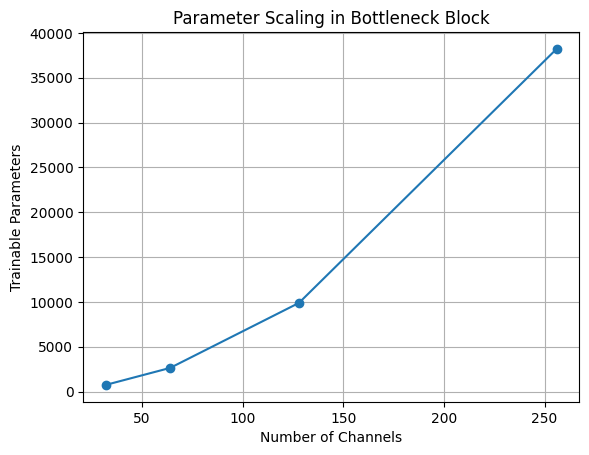

In [19]:
plt.plot(
    channel_sizes,
    parameter_counts,
    marker="o"
)

plt.xlabel(
    "Number of Channels"
)

plt.ylabel(
    "Trainable Parameters"
)

plt.title(
    "Parameter Scaling in Bottleneck Block"
)

plt.grid()

plt.show()

In [20]:
import time

In [21]:
execution_times = []

for channels in channel_sizes:

    bottleneck_channels = channels // 4

    test_model = CustomBottleneck(
        channels,
        bottleneck_channels,
        channels
    ).to(device)

    test_input = torch.randn(
        2,
        channels,
        32,
        32
    ).to(device)

    test_model.eval()

    start = time.time()

    for _ in range(20):

        with torch.no_grad():

            _ = test_model(
                test_input
            )

    end = time.time()

    average_time = (
        end - start
    ) / 20

    execution_times.append(
        average_time
    )

    print(
        f"Channels: {channels:3d} "
        f"| Time: {average_time:.6f} sec"
    )

Channels:  32 | Time: 0.001067 sec
Channels:  64 | Time: 0.001349 sec
Channels: 128 | Time: 0.002745 sec
Channels: 256 | Time: 0.007596 sec


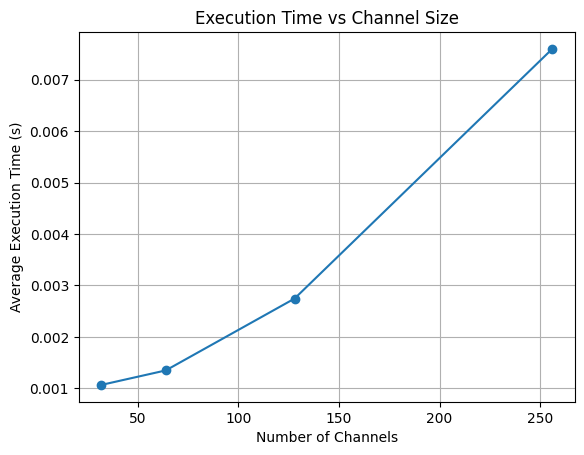

In [22]:
plt.plot(
    channel_sizes,
    execution_times,
    marker="o"
)

plt.xlabel(
    "Number of Channels"
)

plt.ylabel(
    "Average Execution Time (s)"
)

plt.title(
    "Execution Time vs Channel Size"
)

plt.grid()

plt.show()